# Pulsar Energy Loss – Supervised Learning Regression

This notebook applies **Ridge Regression** to predict the **magnetic dipole radiation power loss** of a pulsar (rotating neutron star), governed by the Larmor formula:

$$\dot{E} = -\frac{2\pi}{3\mu_0 c^3} B^2 R^6 \omega^4 \sin^2(\alpha)$$

Two feature sets are compared:
- **Standard Features (SFs):** raw physical quantities (R, B, ω, α, P, m, I, E)
- **Physics-Informed Features (SPIFs):** derived power-like terms built from the Larmor formula

A second SPIF variant (**SPIFs\***) excludes the dominant Larmor term (Power1) to test whether the remaining features alone carry enough information.

## 1. Imports

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.svm import SVR
import matplotlib.pyplot as plt


## 2. Synthetic Dataset Generation

8000 pulsar samples are generated with physically realistic parameter ranges.

The target is the **instantaneous spin-down power** $\dot{E}$ (W), computed from the magnetic dipole radiation formula. Gaussian noise at 50% amplitude is added to simulate measurement uncertainty.

               R             B       omega     alpha         P             m  \
0  380794.717659  7.202959e+11    5.397207  1.076825  1.164155  2.831989e+30   
1  951207.163346  6.873143e+11    1.329829  0.734459  4.724807  2.809553e+30   
2  734674.002393  9.584462e+10  472.791197  0.087504  0.013290  3.069251e+30   
3  602671.899355  9.225801e+11   30.264411  1.442792  0.207610  3.759185e+30   
4  164458.454038  5.685154e+11  974.558021  1.539897  0.006447  3.885697e+30   

              I             E   energy_loss  
0  1.642606e+41  2.392443e+42 -8.244161e+40  
1  1.016828e+42  8.991022e+41 -3.460937e+40  
2  6.626462e+41  7.406115e+46 -3.691998e+46  
3  5.461546e+41  2.501209e+44 -2.284388e+45  
4  4.203793e+40  1.996304e+46 -4.704401e+47  
Relative error (mean): 0.40187437530996345


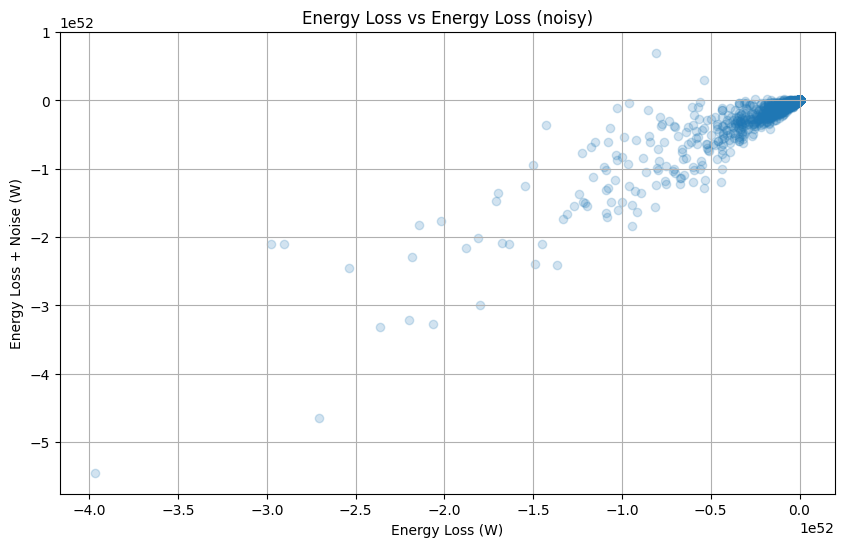

In [9]:
np.random.seed(42)

# --- Physical constants ---
c   = 3.0e8          # speed of light (m/s)
mu0 = 4 * np.pi * 1e-7  # vacuum permeability (H/m)

# --- Pulsar parameters (8000 synthetic samples) ---
R     = np.random.uniform(1e4, 1e6, 8000)        # radius (m): typical NS range 10–1000 km
B     = np.random.uniform(1e8, 1e12, 8000)       # surface magnetic field (T)
omega = np.random.uniform(1, 1e3, 8000)          # angular velocity (rad/s)
alpha = np.random.uniform(0, np.pi / 2, 8000)    # magnetic inclination angle (rad)
m     = np.random.uniform(2.8e30, 4e30, 8000)    # mass (kg): 1.4–2 M☉

# --- Derived quantities ---
P = 2 * np.pi / omega          # rotation period (s)
I = (2 * m * R**2) / 5         # moment of inertia (kg m²), solid sphere approximation
E = (2 * np.pi**2 * I) / P**2  # rotational kinetic energy (J)

# --- Magnetic dipole radiation power loss (Larmor formula) ---
# dE/dt = -(2π / 3μ₀c³) B² R⁶ ω⁴ sin²(α)
energy_loss = -(2 * np.pi / (3 * mu0 * c**3)) * B**2 * R**6 * omega**4 * np.sin(alpha)**2

# Add Gaussian noise with amplitude proportional to |dE/dt| (50% noise level)
noise = np.random.normal(0, 0.5 * np.abs(energy_loss), size=energy_loss.shape)
energy_loss_noise = energy_loss + noise

# --- Summary dataframe ---
data = {
    'R': R, 'B': B, 'omega': omega, 'alpha': alpha,
    'P': P, 'm': m, 'I': I, 'E': E,
    'energy_loss': energy_loss_noise
}
df = pd.DataFrame(data)
print(df.head())

relative_error = np.abs(energy_loss - energy_loss_noise) / np.abs(energy_loss)
print(f"Relative error (mean): {relative_error.mean()}")

# Scatter plot: clean vs noisy energy loss
plt.figure(figsize=(10, 6))
plt.scatter(energy_loss, energy_loss_noise, alpha=0.2)
plt.title('Energy Loss vs Energy Loss (noisy)')
plt.xlabel('Energy Loss (W)')
plt.ylabel('Energy Loss + Noise (W)')
plt.grid(True)
plt.show()


## 3. Standard Features (SFs) – Preprocessing

Features: R, B, ω, α, P, m, I, E (raw physical quantities).  
Data is split 80/20 and standardized with `StandardScaler` (zero mean, unit variance).

In [10]:
# --- Standard Features (SFs) dataframe ---
# Raw physical quantities: R, B, ω, α, P, m, I, E
data_feat = {
    'R': R, 'B': B, 'omega': omega, 'alpha': alpha,
    'P': P, 'm': m, 'I': I, 'E': E,
    'energy_loss': energy_loss_noise
}

df_feat = pd.DataFrame(data_feat)
print(df_feat.head())

# Separate features (X) and target (Y)
X_feat = df_feat.drop(columns=['energy_loss'])
Y_feat = df_feat['energy_loss']

# 80/20 train-test split
X_train_feat, X_test_feat, Y_train_feat, Y_test_feat = train_test_split(
    X_feat, Y_feat, test_size=0.2, random_state=42
)

# Standardize features and target independently (zero mean, unit variance)
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_feat_scaled = scaler_X.fit_transform(X_train_feat)
Y_train_feat_scaled = scaler_Y.fit_transform(Y_train_feat.values.reshape(-1, 1)).flatten()
X_test_feat_scaled  = scaler_X.transform(X_test_feat)
Y_test_feat_scaled  = scaler_Y.transform(Y_test_feat.values.reshape(-1, 1)).flatten()

print(f"TRAIN: {X_train_feat_scaled}, {Y_train_feat_scaled}")
print(f"TEST: {X_test_feat_scaled}, {Y_test_feat_scaled}")


               R             B       omega     alpha         P             m  \
0  380794.717659  7.202959e+11    5.397207  1.076825  1.164155  2.831989e+30   
1  951207.163346  6.873143e+11    1.329829  0.734459  4.724807  2.809553e+30   
2  734674.002393  9.584462e+10  472.791197  0.087504  0.013290  3.069251e+30   
3  602671.899355  9.225801e+11   30.264411  1.442792  0.207610  3.759185e+30   
4  164458.454038  5.685154e+11  974.558021  1.539897  0.006447  3.885697e+30   

              I             E   energy_loss  
0  1.642606e+41  2.392443e+42 -8.244161e+40  
1  1.016828e+42  8.991022e+41 -3.460937e+40  
2  6.626462e+41  7.406115e+46 -3.691998e+46  
3  5.461546e+41  2.501209e+44 -2.284388e+45  
4  4.203793e+40  1.996304e+46 -4.704401e+47  
TRAIN: [[-3.04639081e-01  1.42912261e+00 -1.70584997e+00 ... -1.26047294e+00
  -6.10850523e-01 -6.82476587e-01]
 [-7.84764299e-01  9.07504171e-01 -3.68721213e-01 ...  1.15314513e+00
  -8.23049514e-01 -6.00570136e-01]
 [ 6.28273957e-01 -1.06606

### 3.1 Ridge Regression on Standard Features

5-fold cross-validated `GridSearchCV` with α = 10000 (strong regularization, needed due to the large dynamic range of the raw features).  
Coefficients are back-transformed to the original (unstandardized) domain.

In [11]:
# --- Ridge Regression on Standard Features ---
# fit_intercept=True includes a bias term in the model
ridge = Ridge(fit_intercept=True)

# Fixed regularization strength selected after preliminary log-space sweep
alphas = np.logspace(-4, 8, 100)  # exploratory range (not passed to GridSearchCV)
param_grid = {
    'alpha': [10000]
}

# 5-fold CV scored by negative MAE
grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_feat_scaled, Y_train_feat_scaled)

best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

# Evaluate on test set
best_model  = grid_search.best_estimator_
Y_pred_feat = best_model.predict(X_test_feat_scaled)

mae1 = mean_absolute_error(Y_test_feat_scaled, Y_pred_feat)
mse1 = mean_squared_error(Y_test_feat_scaled, Y_pred_feat)
print(f"MAE test: ", mae1)
print(f"MSE test: ", mse1)

# Normalized relative error: n * MSE / ||y||²
err_rel = np.shape(Y_test_feat_scaled)[0] * mse1 / (np.linalg.norm(Y_test_feat_scaled)**2)
print('norm', np.linalg.norm(Y_test_feat_scaled))
print(f"Relative error new: {err_rel}")

print(f"Coefficients (weights): {best_model.coef_}")

intercept = best_model.intercept_
print(f"Intercept: {intercept}")

# Back-transform coefficients to the original (unstandardized) domain.
# For StandardScaler: β_orig = β_scaled * σ_y / σ_x
# Reference: https://stats.stackexchange.com/questions/393581
stdev_y = np.std(Y_train_feat, ddof=1)
stdev_X = np.std(X_train_feat, axis=0, ddof=1)
original_coefs = (best_model.coef_ * stdev_y) / stdev_X

print(f"Original coefficients (weights): {original_coefs}")
print(f"stdev_y: {stdev_y}")
print(f"stdev_X: {stdev_X}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best alpha: 10000
MAE test:  0.24956705973185037
MSE test:  0.5969902829565567
norm 34.516946582978186
Relative error new: 0.8017196054172071
Coefficients (weights): [-0.0336051  -0.05740447 -0.04362113 -0.05305047  0.00088909  0.0050498
 -0.0507733  -0.15082556]
Intercept: 4.065336259281734e-17
Original coefficients (weights): R       -2.251448e+44
B       -3.818344e+38
omega   -2.908766e+47
alpha   -2.257767e+50
P        8.868415e+48
m        2.798574e+19
I       -2.383696e+08
E       -2.523258e+03
dtype: float64
stdev_y: 1.91914216879899e+51
stdev_X: R        2.864510e+05
B        2.885212e+11
omega    2.878030e+02
alpha    4.509385e-01
P        1.924014e-01
m        3.462938e+29
I        4.087820e+41
E        1.147151e+47
dtype: float64


## 4. Physics-Informed Features (SPIFs) – Preprocessing

Each SPIF is a power-like quantity (W) derived from the Larmor formula and pulsar energetics. Two variants are prepared:

- **Full set** (Power1–Power7): includes the dominant Larmor term Power1 = B²R⁶ω⁴sin²(α)/(μ₀c³)
- **Reduced set** (Power2–Power7): Power1 excluded, to assess the contribution of secondary terms


| Label  | Expression                              | Physical meaning              |
|--------|-----------------------------------------|-------------------------------|
| Power1 | -B² R⁶ ω⁴ sin²(α) / (μ₀ c³)           | Larmor dipole radiation term  |
| Power2 | -B² R⁴ ω / μ₀                          | Magnetic energy × spin rate   |
| Power3 | -B² c⁴ sin(α) / (ω³ μ₀)               | High-c, low-ω radiation term  |
| Power4 | -E / P                                  | Rotational energy / period    |
| Power5 | -I / P³                                 | Inertia / period³             |
| Power6 | -m R² / P³                              | Mass-radius / period³         |
| Power7 | -m R² ω³                                | Mass-radius × spin³           |

In [12]:
# --- Physics-Informed Features (SPIFs) dataframe – full set (Power1 included) ---
# Each feature is a power-like quantity with the same units as dE/dt (W),
# derived from the magnetic dipole radiation formula and pulsar energetics.
#


data_op = {
    'Power1': -(B**2 * R**6 * omega**4 * np.sin(alpha)**2 / (mu0 * c**3)),
    'Power2': -((B**2 * R**4 * omega) / mu0),
    'Power3': -(B**2 * c**4 * np.sin(alpha) / (omega**3 * mu0)),
    'Power4': -(E / P),
    'Power5': -(I / P**3),
    'Power6': -(m * R**2 / P**3),
    'Power7': -(m * R**2 * omega**3),
    'energy_loss': energy_loss_noise
}

df_op = pd.DataFrame(data_op)
print(df_op.head())

# Separate features (X) and target (Y)
X_op = df_op.drop(columns=['energy_loss'])
Y_op = df_op['energy_loss']

# 80/20 train-test split
X_train_op, X_test_op, Y_train_op, Y_test_op = train_test_split(
    X_op, Y_op, test_size=0.2, random_state=42
)

# Standardize features and target independently
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_op_scaled = scaler_X.fit_transform(X_train_op)
Y_train_op_scaled = scaler_Y.fit_transform(Y_train_op.values.reshape(-1, 1)).flatten()
X_test_op_scaled  = scaler_X.transform(X_test_op)
Y_test_op_scaled  = scaler_Y.transform(Y_test_op.values.reshape(-1, 1)).flatten()

print(f"TRAIN: {X_train_op_scaled}, {Y_train_op_scaled}")
print(f"TEST: {X_test_op_scaled}, {Y_test_op_scaled}")


         Power1        Power2        Power3        Power4        Power5  \
0 -3.066806e+40 -4.685380e+52 -1.872828e+61 -2.055090e+42 -1.041121e+41   
1 -1.448642e+40 -4.092580e+53 -8.677476e+62 -1.902940e+41 -9.640405e+39   
2 -1.624637e+46 -1.006871e+54 -4.896401e+52 -5.572883e+48 -2.823256e+47   
3 -9.920047e+44 -2.704297e+54 -1.962994e+59 -1.204765e+45 -6.103412e+43   
4 -1.698494e+47 -1.833610e+53 -2.249723e+54 -3.096382e+48 -1.568646e+47   

         Power6        Power7   energy_loss  
0 -2.602802e+41 -6.456256e+43 -8.244161e+40  
1 -2.410101e+40 -5.978261e+42 -3.460937e+40  
2 -7.058139e+47 -1.750773e+50 -3.691998e+46  
3 -1.525853e+44 -3.784882e+46 -2.284388e+45  
4 -3.921614e+47 -9.727572e+49 -4.704401e+47  
TRAIN: [[ 1.95225597e-01  4.20356848e-01  4.42034088e-03 ...  5.80860152e-01
   5.80860152e-01  5.80860152e-01]
 [ 1.95005598e-01  4.09532365e-01  3.28646603e-02 ...  5.43281580e-01
   5.43281580e-01  5.43281580e-01]
 [ 1.44944872e-01  3.50601247e-01  3.28675328e-02 ... -9

In [13]:
# --- Physics-Informed Features (SPIFs) – reduced set (Power1 excluded) ---
# Same pipeline as the full SPIF set, but Power1
# is removed to assess whether the remaining features alone can predict dE/dt.

data_op_bis = {
    'Power2': -((B**2 * R**4 * omega) / mu0),
    'Power3': -(B**2 * c**4 * np.sin(alpha) / (omega**3 * mu0)),
    'Power4': -(E / P),
    'Power5': -(I / P**3),
    'Power6': -(m * R**2 / P**3),
    'Power7': -(m * R**2 * omega**3),
    'energy_loss': energy_loss_noise
}

df_op_bis = pd.DataFrame(data_op_bis)
print(df_op_bis.head())

# Separate features (X) and target (Y)
X_op_bis = df_op_bis.drop(columns=['energy_loss'])
Y_op_bis = df_op_bis['energy_loss']

# 80/20 train-test split
X_train_op_bis, X_test_op_bis, Y_train_op_bis, Y_test_op_bis = train_test_split(
    X_op_bis, Y_op_bis, test_size=0.2, random_state=42
)

# Standardize features and target independently
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_op_bis_scaled = scaler_X.fit_transform(X_train_op_bis)
Y_train_op_bis_scaled = scaler_Y.fit_transform(Y_train_op_bis.values.reshape(-1, 1)).flatten()
X_test_op_bis_scaled  = scaler_X.transform(X_test_op_bis)
Y_test_op_bis_scaled  = scaler_Y.transform(Y_test_op_bis.values.reshape(-1, 1)).flatten()

print(f"TRAIN: {X_train_op_bis_scaled}, {Y_train_op_bis_scaled}")
print(f"TEST: {X_test_op_bis_scaled}, {Y_test_op_bis_scaled}")


         Power2        Power3        Power4        Power5        Power6  \
0 -4.685380e+52 -1.872828e+61 -2.055090e+42 -1.041121e+41 -2.602802e+41   
1 -4.092580e+53 -8.677476e+62 -1.902940e+41 -9.640405e+39 -2.410101e+40   
2 -1.006871e+54 -4.896401e+52 -5.572883e+48 -2.823256e+47 -7.058139e+47   
3 -2.704297e+54 -1.962994e+59 -1.204765e+45 -6.103412e+43 -1.525853e+44   
4 -1.833610e+53 -2.249723e+54 -3.096382e+48 -1.568646e+47 -3.921614e+47   

         Power7   energy_loss  
0 -6.456256e+43 -8.244161e+40  
1 -5.978261e+42 -3.460937e+40  
2 -1.750773e+50 -3.691998e+46  
3 -3.784882e+46 -2.284388e+45  
4 -9.727572e+49 -4.704401e+47  
TRAIN: [[ 0.42035685  0.00442034  0.58086015  0.58086015  0.58086015  0.58086015]
 [ 0.40953236  0.03286466  0.54328158  0.54328158  0.54328158  0.54328158]
 [ 0.35060125  0.03286753 -0.99807015 -0.99807015 -0.99807015 -0.99807015]
 ...
 [-0.1019082   0.03286739  0.17188466  0.17188466  0.17188466  0.17188466]
 [-4.30453205  0.03286723 -2.55600781 -2.5560

### 4.1 Ridge Regression on SPIFs – Full Set (Power1 included)

Features are added incrementally in descending order of |coefficient| to detect the saturation point where additional SPIFs no longer improve MAE.

In [14]:
# --- Ridge Regression on Physics-Informed Features ---
ridge = Ridge(fit_intercept=True)

alphas = np.logspace(-3, 3, 100)  # exploratory range
param_grid = {
    'alpha': [100]
}

grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_op_scaled, Y_train_op_scaled)

best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

best_model    = grid_search.best_estimator_
Y_pred_op = best_model.predict(X_test_op_scaled)

mae1 = mean_absolute_error(Y_test_op_scaled, Y_pred_op)
mse1 = mean_squared_error(Y_test_op_scaled, Y_pred_op)
print(f"MAE test: ", mae1)
print(f"MSE test: ", mse1)

# Normalized relative error: n * MSE / ||y||²
err_rel = np.shape(Y_test_op_scaled)[0] * mse1 / (np.linalg.norm(Y_test_op_scaled)**2)
print('norm', np.linalg.norm(Y_test_op_scaled))
print(f"Relative error new: {err_rel}")

print(f"Coefficients (weights): {best_model.coef_}")

# --- Incremental feature importance analysis ---
# Sort features by descending |coefficient| and add them one by one,
# tracking how MAE evolves to identify the saturation point.
feature_names        = X_op.columns
sorted_indices       = np.argsort(np.abs(best_model.coef_))[::-1]  # descending |coef|
sorted_feature_names = feature_names[sorted_indices]

mae_list       = []
added_features = []

Y_cumulative = X_test_op_scaled[:, sorted_indices[0]] * best_model.coef_[sorted_indices[0]]
mae = mean_absolute_error(Y_test_op_scaled, Y_cumulative)
mae_list.append(mae)
added_features.append(sorted_feature_names[0])
for i in range(1, len(best_model.coef_)):
    Y_cumulative += X_test_op_scaled[:, sorted_indices[i]] * best_model.coef_[sorted_indices[i]]
    mae = mean_absolute_error(Y_test_op_scaled, Y_cumulative)
    mae_list.append(mae)
    added_features.append(sorted_feature_names[i])
for idx, (mae, feature) in enumerate(zip(mae_list, added_features)):
    print(f"MAE after adding feature '{feature}' ({idx+1}): {mae}")

intercept = best_model.intercept_
print(f"Intercept: {intercept}")

# Back-transform coefficients to the original (unstandardized) domain.
# Reference: https://stats.stackexchange.com/questions/393581
stdev_y = np.std(Y_train_op, ddof=1)
stdev_X = np.std(X_train_op, axis=0, ddof=1)
original_coefs = (best_model.coef_ * stdev_y) / stdev_X

print(f"Original coefficients (weights): {original_coefs}")
print(f"stdev_y: {stdev_y}")
print(f"stdev_X: {stdev_X}")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best alpha: 100
MAE test:  0.06639354958126784
MSE test:  0.12848837503138685
norm 34.516946582978186
Relative error new: 0.1725516348787168
Coefficients (weights): [ 9.25706122e-01 -1.36517839e-02  2.64752933e-05 -8.76883671e-04
 -8.76883671e-04 -8.76883671e-04 -8.76883671e-04]
MAE after adding feature 'Power1' (1): 0.07038407110681896
MAE after adding feature 'Power2' (2): 0.06731065442694945
MAE after adding feature 'Power6' (3): 0.06707177629466797
MAE after adding feature 'Power5' (4): 0.06683945245409195
MAE after adding feature 'Power7' (5): 0.0666143417411861
MAE after adding feature 'Power4' (6): 0.06639353751642497
MAE after adding feature 'Power3' (7): 0.06639354958126782
Intercept: 2.206592792202003e-17
Original coefficients (weights): Power1    2.302142e+00
Power2   -4.160310e-07
Power3    2.850345e-15
Power4   -1.040128e-01
Power5   -2.053131e+00
Power6   -8.212523e-01
Power7   -3.310831e-03
dtype: float64
stdev_y

### 4.2 Ridge Regression on SPIFs – Reduced Set (Power1 excluded)

Same incremental analysis as above, but on the reduced feature set. Comparing the two variants reveals how much predictive power is carried by Power1 alone.

In [15]:
# --- Ridge Regression on Physics-Informed Features (Power1 excluded) ---
ridge = Ridge(fit_intercept=True)

alphas = np.logspace(-3, 8, 100)  # exploratory range
param_grid = {
    'alpha': [100]
}

grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1
)
grid_search.fit(X_train_op_bis_scaled, Y_train_op_bis_scaled)

best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

best_model    = grid_search.best_estimator_
Y_pred_op_bis = best_model.predict(X_test_op_bis_scaled)

mae1 = mean_absolute_error(Y_test_op_bis_scaled, Y_pred_op_bis)
mse1 = mean_squared_error(Y_test_op_bis_scaled, Y_pred_op_bis)
print(f"MAE test: ", mae1)
print(f"MSE test: ", mse1)

# Normalized relative error: n * MSE / ||y||²
err_rel = np.shape(Y_test_op_bis_scaled)[0] * mse1 / (np.linalg.norm(Y_test_op_bis_scaled)**2)
print('norm', np.linalg.norm(Y_test_op_bis_scaled))
print(f"Relative error new: {err_rel}")

print(f"Coefficients (weights): {best_model.coef_}")

# --- Incremental feature importance analysis ---
# Sort features by descending |coefficient| and add them one by one,
# tracking how MAE evolves to identify the saturation point.
feature_names        = X_op_bis.columns
sorted_indices       = np.argsort(np.abs(best_model.coef_))[::-1]  # descending |coef|
sorted_feature_names = feature_names[sorted_indices]

mae_list       = []
added_features = []

Y_cumulative = X_test_op_bis_scaled[:, sorted_indices[0]] * best_model.coef_[sorted_indices[0]]
mae = mean_absolute_error(Y_test_op_bis_scaled, Y_cumulative)
mae_list.append(mae)
added_features.append(sorted_feature_names[0])
for i in range(1, len(best_model.coef_)):
    Y_cumulative += X_test_op_bis_scaled[:, sorted_indices[i]] * best_model.coef_[sorted_indices[i]]
    mae = mean_absolute_error(Y_test_op_bis_scaled, Y_cumulative)
    mae_list.append(mae)
    added_features.append(sorted_feature_names[i])
for idx, (mae, feature) in enumerate(zip(mae_list, added_features)):
    print(f"MAE after adding feature '{feature}' ({idx+1}): {mae}")

intercept = best_model.intercept_
print(f"Intercept: {intercept}")

# Back-transform coefficients to the original (unstandardized) domain.
# Reference: https://stats.stackexchange.com/questions/393581
stdev_y = np.std(Y_train_op_bis, ddof=1)
stdev_X = np.std(X_train_op_bis, axis=0, ddof=1)
original_coefs = (best_model.coef_ * stdev_y) / stdev_X

print(f"Original coefficients (weights): {original_coefs}")
print(f"stdev_y: {stdev_y}")
print(f"stdev_X: {stdev_X}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best alpha: 100
MAE test:  0.2607344528699908
MSE test:  0.40604785380787356
norm 34.516946582978186
Relative error new: 0.5452961872731883
Coefficients (weights): [0.49037656 0.00481584 0.04905554 0.04905554 0.04905554 0.04905554]
MAE after adding feature 'Power2' (1): 0.18662856633916453
MAE after adding feature 'Power5' (2): 0.19898551107587906
MAE after adding feature 'Power4' (3): 0.217751761686955
MAE after adding feature 'Power7' (4): 0.23842808335720148
MAE after adding feature 'Power6' (5): 0.2608226016202242
MAE after adding feature 'Power3' (6): 0.2607344528699908
Intercept: 1.5765595716774595e-17
Original coefficients (weights): Power2    1.494397e-05
Power3    5.184765e-13
Power4    5.818794e+00
Power5    1.148584e+02
Power6    4.594335e+01
Power7    1.852180e-01
dtype: float64
stdev_y: 1.91914216879899e+51
stdev_X: Power2    6.297538e+55
Power3    1.782586e+61
Power4    1.617939e+49
Power5    8.196577e+47
Power6  

## 5. Error Analysis – Boxplots

Absolute and squared errors are compared across the three feature sets (SPIFs full, SPIFs reduced, SFs) after IQR-based outlier removal.  
Mean (red dot) and median (blue bar) are shown explicitly inside each box.

Absolute Errors SPIFs  – median: 0.0019491588882858402 mean: 0.06639354958126784
Absolute Errors SPIFs* – median: 0.14140609258564024 mean: 0.2607344528699908
Absolute Errors SFs    – median: 0.12578815040439456 mean: 0.24956705973185037
Absolute Errors SPIFs  (filtered) – median: 0.0013931408148475377 mean: 0.003334739681664625
Absolute Errors SPIFs* (filtered) – median: 0.1330113113891636 mean: 0.11699187356354827
Absolute Errors SFs    (filtered) – median: 0.11679437850203969 mean: 0.13998631834030736


/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_22987/275869031.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)


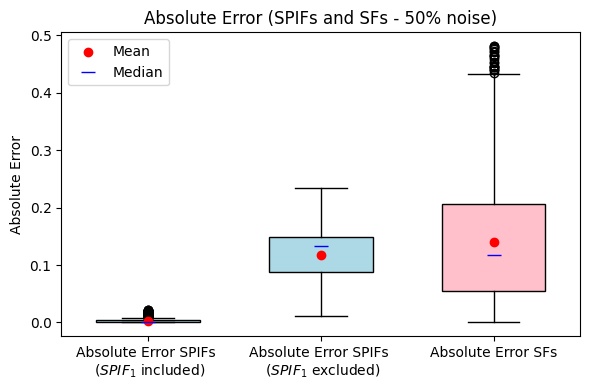

In [16]:
# --- Absolute error comparison: SPIFs (full), SPIFs (reduced), SFs ---
absolute_errors_op = []
for true_value, predicted_value in zip(Y_test_op_scaled, Y_pred_op):
    absolute_errors_op.append(abs(true_value - predicted_value))

absolute_errors_op_bis = []
for true_value, predicted_value in zip(Y_test_op_bis_scaled, Y_pred_op_bis):
    absolute_errors_op_bis.append(abs(true_value - predicted_value))

absolute_errors_feat = []
for true_value, predicted_value in zip(Y_test_feat_scaled, Y_pred_feat):
    absolute_errors_feat.append(abs(true_value - predicted_value))

print("Absolute Errors SPIFs  – median:", np.median(absolute_errors_op),  "mean:", np.mean(absolute_errors_op))
print("Absolute Errors SPIFs* – median:", np.median(absolute_errors_op_bis), "mean:", np.mean(absolute_errors_op_bis))
print("Absolute Errors SFs    – median:", np.median(absolute_errors_feat), "mean:", np.mean(absolute_errors_feat))

# Remove outliers using the IQR rule: discard values outside [Q1 - 1.5·IQR, Q3 + 1.5·IQR]
def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if lower_bound <= x <= upper_bound]

absolute_errors_op     = remove_outliers(absolute_errors_op)
absolute_errors_feat   = remove_outliers(absolute_errors_feat)
absolute_errors_op_bis = remove_outliers(absolute_errors_op_bis)

print("Absolute Errors SPIFs  (filtered) – median:", np.median(absolute_errors_op),  "mean:", np.mean(absolute_errors_op))
print("Absolute Errors SPIFs* (filtered) – median:", np.median(absolute_errors_op_bis), "mean:", np.mean(absolute_errors_op_bis))
print("Absolute Errors SFs    (filtered) – median:", np.median(absolute_errors_feat), "mean:", np.mean(absolute_errors_feat))

colors = {'op': 'lightblue', 'feat': 'pink'}

def create_boxplot(data, labels, title):
    plt.figure(figsize=(6, 4))
    # patch_artist fills boxes with color; default median line is hidden
    box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)

    for patch, label in zip(box['boxes'], labels):
        if 'PIFs' in label:
            patch.set_facecolor(colors['op'])
        else:
            patch.set_facecolor(colors['feat'])

    # Hide default median line; redraw mean and median as explicit markers
    for median in box['medians']:
        median.set_visible(False)

    means   = [np.mean(d) for d in data]
    medians = [np.median(d) for d in data]

    plt.scatter(range(1, len(labels) + 1), means,   marker='o', color='red',  zorder=3, label='Mean')
    plt.plot(   range(1, len(labels) + 1), medians, marker='_', color='blue', markersize=10,
                linestyle='None', zorder=4, label='Median')

    plt.title(title)
    plt.ylabel('Absolute Error')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

data   = [absolute_errors_op, absolute_errors_op_bis, absolute_errors_feat]
labels = ['Absolute Error SPIFs \n ($SPIF_{{{1}}}$ included)',
          'Absolute Error SPIFs \n ($SPIF_{{{1}}}$ excluded)',
          'Absolute Error SFs']

create_boxplot(data, labels, 'Absolute Error (SPIFs and SFs - 50% noise)')


Squared Errors SPIFs  – median: 3.79927234380731e-06 mean: 0.12848837503138685
Squared Errors SPIFs* – median: 0.01999568489945385 mean: 0.40604785380787356
Squared Errors SFs    – median: 0.015822675290334487 mean: 0.5969902829565567
Squared Errors SPIFs  (filtered) – median: 1.704980536507027e-06 mean: 1.6196822668847282e-05
Squared Errors SPIFs* (filtered) – median: 0.016898171980888957 mean: 0.014643954283123676
Squared Errors SFs    (filtered) – median: 0.012427319289979132 mean: 0.024212793804241652


/var/folders/4z/h4bn93s156x_ryx0jtgspqy40000gn/T/ipykernel_22987/3005827138.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)


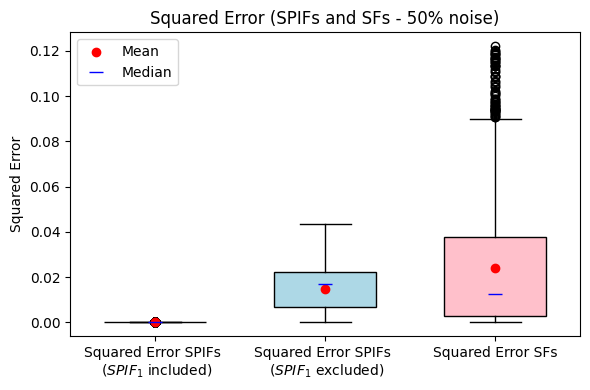

In [17]:
# --- Squared error comparison: SPIFs (full), SPIFs (reduced), SFs ---
squared_errors_op = []
for true_value, predicted_value in zip(Y_test_op_scaled, Y_pred_op):
    squared_errors_op.append(abs(true_value - predicted_value)**2)

squared_errors_op_bis = []
for true_value, predicted_value in zip(Y_test_op_bis_scaled, Y_pred_op_bis):
    squared_errors_op_bis.append(abs(true_value - predicted_value)**2)

squared_errors_feat = []
for true_value, predicted_value in zip(Y_test_feat_scaled, Y_pred_feat):
    squared_errors_feat.append(abs(true_value - predicted_value)**2)

print("Squared Errors SPIFs  – median:", np.median(squared_errors_op),  "mean:", np.mean(squared_errors_op))
print("Squared Errors SPIFs* – median:", np.median(squared_errors_op_bis), "mean:", np.mean(squared_errors_op_bis))
print("Squared Errors SFs    – median:", np.median(squared_errors_feat), "mean:", np.mean(squared_errors_feat))

# Remove outliers using the IQR rule
def remove_outliers(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return [x for x in data if lower_bound <= x <= upper_bound]

squared_errors_op     = remove_outliers(squared_errors_op)
squared_errors_feat   = remove_outliers(squared_errors_feat)
squared_errors_op_bis = remove_outliers(squared_errors_op_bis)

print("Squared Errors SPIFs  (filtered) – median:", np.median(squared_errors_op),  "mean:", np.mean(squared_errors_op))
print("Squared Errors SPIFs* (filtered) – median:", np.median(squared_errors_op_bis), "mean:", np.mean(squared_errors_op_bis))
print("Squared Errors SFs    (filtered) – median:", np.median(squared_errors_feat), "mean:", np.mean(squared_errors_feat))

colors = {'op': 'lightblue', 'feat': 'pink'}

def create_boxplot(data, labels, title):
    plt.figure(figsize=(6, 4))
    box = plt.boxplot(data, labels=labels, patch_artist=True, showmeans=False, widths=0.6)

    for patch, label in zip(box['boxes'], labels):
        if 'PIFs' in label:
            patch.set_facecolor(colors['op'])
        else:
            patch.set_facecolor(colors['feat'])

    for median in box['medians']:
        median.set_visible(False)

    means   = [np.mean(d) for d in data]
    medians = [np.median(d) for d in data]

    plt.scatter(range(1, len(labels) + 1), means,   marker='o', color='red',  zorder=3, label='Mean')
    plt.plot(   range(1, len(labels) + 1), medians, marker='_', color='blue', markersize=10,
                linestyle='None', zorder=4, label='Median')

    plt.title(title)
    plt.ylabel('Squared Error')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

data   = [squared_errors_op, squared_errors_op_bis, squared_errors_feat]
labels = ['Squared Error SPIFs \n ($SPIF_{{{1}}}$ included)',
          'Squared Error SPIFs \n ($SPIF_{{{1}}}$ excluded)',
          'Squared Error SFs']

create_boxplot(data, labels, 'Squared Error (SPIFs and SFs - 50% noise)')
